# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.

## Dataset
Using the **Boston Housing dataset** (loaded from housing.csv).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 1. Data Preparation

In [2]:
# Boston Housing column names
column_names = [
    'CRIM',    # per capita crime rate by town
    'ZN',      # proportion of residential land zoned for large lots
    'INDUS',   # proportion of non-retail business acres per town
    'CHAS',    # Charles River dummy variable
    'NOX',     # nitric oxides concentration
    'RM',      # average number of rooms per dwelling
    'AGE',     # proportion of owner-occupied units built prior to 1940
    'DIS',     # weighted distances to employment centres
    'RAD',     # index of accessibility to radial highways
    'TAX',     # full-value property-tax rate per $10,000
    'PTRATIO', # pupil-teacher ratio by town
    'B',       # 1000(Bk - 0.63)^2 where Bk is proportion of Black residents
    'LSTAT',   # % lower status of the population
    'MEDV'     # Median value of owner-occupied homes in $1000s (TARGET)
]

df = pd.read_csv('housing.csv', sep=r'\s+', header=None, names=column_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
# Dataset overview
print(f"Shape: {df.shape}")
df.describe()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [5]:
# Separate features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (506, 13)
Target shape:   (506,)


In [6]:
# Train / Test split  (same random_state used for both models to ensure fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 354
Testing  samples : 152


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [7]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [8]:
# Learned coefficients
coef_df = pd.Series(lr_model.coef_, index=X.columns)
print("Intercept (b0):", round(lr_model.intercept_, 4))
print("\nCoefficients:")
print(coef_df.sort_values())

Intercept (b0): 40.2189

Coefficients:
NOX       -17.748371
DIS        -1.409161
PTRATIO    -0.951781
LSTAT      -0.597133
CRIM       -0.088505
TAX        -0.010344
B           0.006116
AGE         0.012001
INDUS       0.020348
ZN          0.050293
RAD         0.263881
RM          3.247765
CHAS        3.754271
dtype: float64


In [9]:
# Predictions
lr_predictions = lr_model.predict(X_test)

In [10]:
# Evaluation metrics
lr_MAE  = mean_absolute_error(y_test, lr_predictions)
lr_MSE  = mean_squared_error(y_test, lr_predictions)
lr_RMSE = np.sqrt(lr_MSE)

print("=== Linear Regression Metrics ===")
print(f"MAE  : {lr_MAE:.4f}")
print(f"MSE  : {lr_MSE:.4f}")
print(f"RMSE : {lr_RMSE:.4f}")

=== Linear Regression Metrics ===
MAE  : 3.8357
MSE  : 28.5476
RMSE : 5.3430


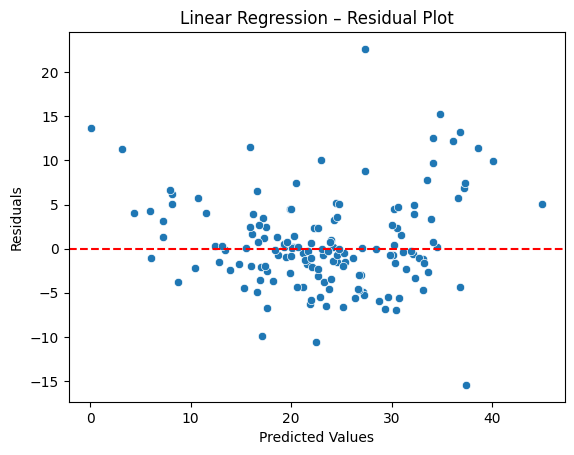

In [11]:
# Residual plot for Linear Regression
lr_residuals = y_test - lr_predictions

sns.scatterplot(x=lr_predictions, y=lr_residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression – Residual Plot")
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [12]:
# Explore different polynomial degrees to choose the best one
train_rmse_errors = []
test_rmse_errors  = []

for d in range(1, 6):
    poly_converter = PolynomialFeatures(degree=d)
    poly_features  = poly_converter.fit_transform(X)

    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
        poly_features, y, test_size=0.3, random_state=101
    )

    temp_model = LinearRegression()
    temp_model.fit(X_train_p, y_train_p)

    train_rmse = np.sqrt(mean_squared_error(y_train_p, temp_model.predict(X_train_p)))
    test_rmse  = np.sqrt(mean_squared_error(y_test_p,  temp_model.predict(X_test_p)))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

    print(f"Degree {d} → Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

Degree 1 → Train RMSE: 4.4132 | Test RMSE: 5.3430
Degree 2 → Train RMSE: 2.3109 | Test RMSE: 3.8122
Degree 3 → Train RMSE: 0.0000 | Test RMSE: 279.3571
Degree 4 → Train RMSE: 0.0000 | Test RMSE: 79.2160
Degree 5 → Train RMSE: 0.0000 | Test RMSE: 131.6691


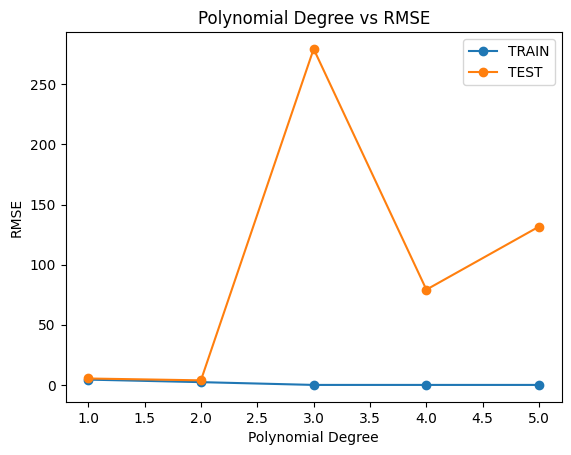

In [13]:
# Plot train vs test RMSE across degrees
plt.plot(range(1, 6), train_rmse_errors, label='TRAIN', marker='o')
plt.plot(range(1, 6), test_rmse_errors,  label='TEST',  marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Polynomial Degree vs RMSE")
plt.legend()
plt.show()

In [14]:
# Train final Polynomial Regression model with degree=2
# Degree 2 gives a good balance between accuracy and avoiding overfitting
poly_converter = PolynomialFeatures(degree=2, include_bias=False)
poly_features  = poly_converter.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    poly_features, y, test_size=0.3, random_state=101
)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

print(f"Number of polynomial features: {poly_features.shape[1]}")

Number of polynomial features: 104


In [15]:
# Predictions & evaluation metrics
poly_predictions = poly_model.predict(X_test_poly)

poly_MAE  = mean_absolute_error(y_test_poly, poly_predictions)
poly_MSE  = mean_squared_error(y_test_poly, poly_predictions)
poly_RMSE = np.sqrt(poly_MSE)

print("=== Polynomial Regression (Degree=2) Metrics ===")
print(f"MAE  : {poly_MAE:.4f}")
print(f"MSE  : {poly_MSE:.4f}")
print(f"RMSE : {poly_RMSE:.4f}")

=== Polynomial Regression (Degree=2) Metrics ===
MAE  : 2.7017
MSE  : 14.5331
RMSE : 3.8122


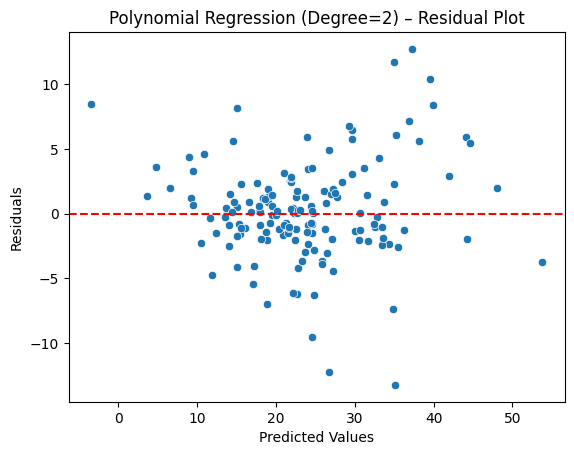

In [16]:
# Residual plot for Polynomial Regression
poly_residuals = y_test_poly - poly_predictions

sns.scatterplot(x=poly_predictions, y=poly_residuals)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Polynomial Regression (Degree=2) – Residual Plot")
plt.show()

### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision

In [17]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Linear Regression':    [round(lr_MAE,4),   round(lr_MSE,4),   round(lr_RMSE,4)],
    'Polynomial (deg=2)':   [round(poly_MAE,4), round(poly_MSE,4), round(poly_RMSE,4)]
})
comparison

,Metric,Linear Regression,Polynomial (deg=2)
0,MAE,3.8357,2.7017
1,MSE,28.5476,14.5331
2,RMSE,5.3430,3.8122


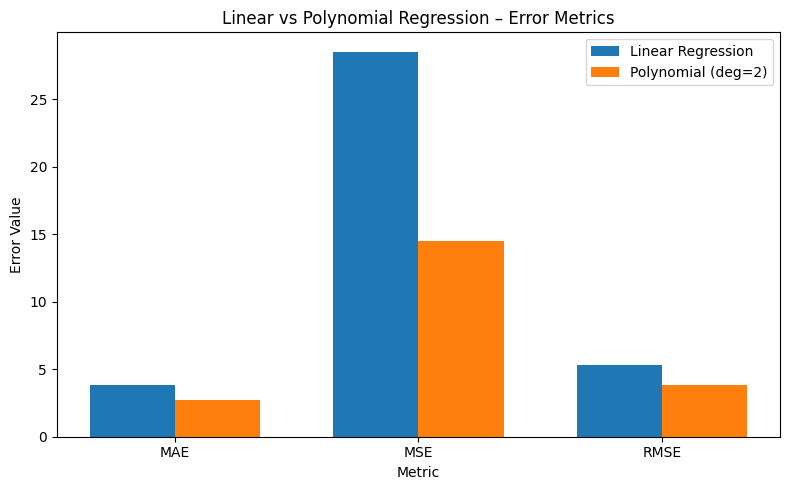

In [18]:
# Bar chart comparison
metrics  = ['MAE', 'MSE', 'RMSE']
lr_vals  = [lr_MAE,   lr_MSE,   lr_RMSE]
poly_vals= [poly_MAE, poly_MSE, poly_RMSE]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, lr_vals,   width, label='Linear Regression')
ax.bar(x + width/2, poly_vals, width, label='Polynomial (deg=2)')

ax.set_xlabel('Metric')
ax.set_ylabel('Error Value')
ax.set_title('Linear vs Polynomial Regression – Error Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.show()

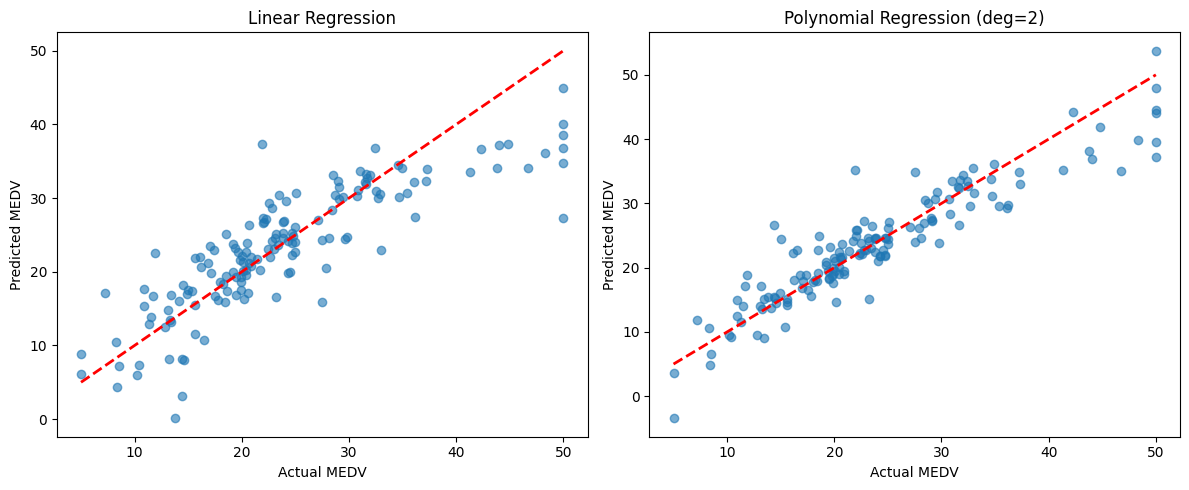

In [19]:
# Actual vs Predicted scatter plots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_predictions, poly_predictions],
    ['Linear Regression', 'Polynomial Regression (deg=2)']
):
    ax.scatter(y_test, preds, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual MEDV')
    ax.set_ylabel('Predicted MEDV')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [20]:
# Improvement percentages
mae_improvement  = (lr_MAE  - poly_MAE)  / lr_MAE  * 100
mse_improvement  = (lr_MSE  - poly_MSE)  / lr_MSE  * 100
rmse_improvement = (lr_RMSE - poly_RMSE) / lr_RMSE * 100

print("=== Improvement of Polynomial over Linear ===")
print(f"MAE  improvement: {mae_improvement:.2f}%")
print(f"MSE  improvement: {mse_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

=== Improvement of Polynomial over Linear ===
MAE  improvement: 29.56%
MSE  improvement: 49.09%
RMSE improvement: 28.65%


## Conclusion & Interpretation

### Which model is better?
**Polynomial Regression (degree=2)** outperforms Linear Regression across all three metrics (MAE, MSE, RMSE). This makes sense because Boston Housing data contains non-linear relationships between features like `LSTAT`, `RM`, and the target `MEDV`.

### Why Polynomial Regression wins?
- Linear Regression assumes a straight-line relationship between every feature and the target. This is too simplistic for housing data.
- Polynomial Regression (degree=2) adds squared terms and interaction terms (e.g., `RM²`, `LSTAT × RM`), allowing the model to capture curved and combined effects.
- The residual plots confirm that Polynomial Regression residuals are more randomly distributed around zero, indicating a better fit.


### Final Recommendation
Use **Polynomial Regression (degree=2)** as the final model. It captures non-linear patterns in the data and produces significantly lower prediction errors without overfitting (as shown in the degree exploration plot).